## Import necessary libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & encoding
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Hugging Face dataset loader
from datasets import load_dataset

# Display options
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

## Load Dataset

In [2]:
dataset = load_dataset("electricsheepafrica/neonatal-sepsis-care")

print(dataset)

df = dataset["train"].to_pandas()

print(df.head())
print(df.info())

DatasetDict({
    train: Dataset({
        features: ['id', 'sex', 'gestational_age_weeks', 'preterm', 'birth_weight_g', 'low_birth_weight', 'very_low_birth_weight', 'delivery_mode', 'place_of_birth', 'maternal_age_years', 'apgar_1min', 'apgar_5min', 'resuscitation_at_birth', 'prom_over_18h', 'maternal_fever', 'maternal_uti', 'unclean_cord_care', 'maternal_hiv', 'multiple_birth', 'anc_4plus', 'onset_type', 'age_at_onset_hours', 'age_at_onset_days', 'temperature_c', 'poor_feeding', 'lethargy', 'respiratory_distress', 'convulsions', 'abdominal_distension', 'jaundice', 'umbilical_redness', 'skin_pustules', 'bulging_fontanelle', 'severity', 'blood_culture_done', 'blood_culture_result', 'organism', 'resistance_pattern', 'crp_done', 'crp_mg_l', 'wbc_done', 'wbc_count', 'platelet_count', 'lumbar_puncture_done', 'csf_result', 'antibiotic_regimen', 'antibiotic_duration_days', 'iv_fluids', 'oxygen_therapy', 'cpap', 'phototherapy', 'kmc', 'exchange_transfusion', 'referred_out', 'outcome', 'length

## EDA

In [3]:
# Check column names
print(df.columns)

# Check missing values
print(df.isnull().sum())

# Summary statistics
print(df.describe())

Index(['id', 'sex', 'gestational_age_weeks', 'preterm', 'birth_weight_g',
       'low_birth_weight', 'very_low_birth_weight', 'delivery_mode',
       'place_of_birth', 'maternal_age_years', 'apgar_1min', 'apgar_5min',
       'resuscitation_at_birth', 'prom_over_18h', 'maternal_fever',
       'maternal_uti', 'unclean_cord_care', 'maternal_hiv', 'multiple_birth',
       'anc_4plus', 'onset_type', 'age_at_onset_hours', 'age_at_onset_days',
       'temperature_c', 'poor_feeding', 'lethargy', 'respiratory_distress',
       'convulsions', 'abdominal_distension', 'jaundice', 'umbilical_redness',
       'skin_pustules', 'bulging_fontanelle', 'severity', 'blood_culture_done',
       'blood_culture_result', 'organism', 'resistance_pattern', 'crp_done',
       'crp_mg_l', 'wbc_done', 'wbc_count', 'platelet_count',
       'lumbar_puncture_done', 'csf_result', 'antibiotic_regimen',
       'antibiotic_duration_days', 'iv_fluids', 'oxygen_therapy', 'cpap',
       'phototherapy', 'kmc', 'exchange_tran

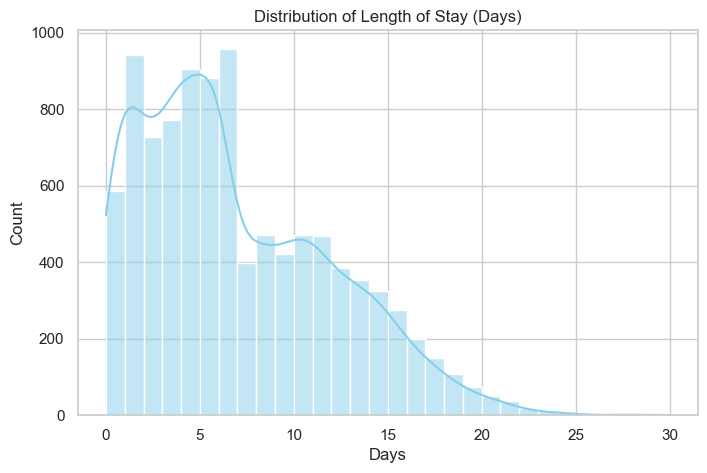

In [4]:
# Observe Distribution of target variable
plt.figure(figsize=(8,5))
sns.histplot(df['length_of_stay_days'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Length of Stay (Days)")
plt.xlabel("Days")
plt.ylabel("Count")
plt.show()

In [5]:
# No missing value handling needed
print(df.isnull().sum().sum())  # should print 0

0


In [6]:
# Define features and target
features = [
    'sex', 'gestational_age_weeks', 'preterm', 'birth_weight_g',
    'low_birth_weight', 'very_low_birth_weight',
    'delivery_mode', 'place_of_birth', 'maternal_age_years',
    'apgar_1min', 'apgar_5min', 'resuscitation_at_birth',
    'prom_over_18h', 'maternal_fever', 'maternal_uti',
    'unclean_cord_care', 'maternal_hiv', 'multiple_birth',
    'anc_4plus', 'temperature_c', 'poor_feeding', 'lethargy',
    'respiratory_distress', 'convulsions',
    'abdominal_distension', 'jaundice', 'umbilical_redness',
    'skin_pustules', 'bulging_fontanelle', 'severity'
]

target = 'length_of_stay_days'

In [7]:
# check min and max of features and target
df[features + [target]].describe().T[['min','max']]

,min,max
gestational_age_weeks,24.0,42.0
preterm,0.0,1.0
birth_weight_g,500.0,4552.0
low_birth_weight,0.0,1.0
very_low_birth_weight,0.0,1.0
maternal_age_years,14.0,48.0
apgar_1min,0.0,10.0
apgar_5min,1.0,10.0
resuscitation_at_birth,0.0,1.0
prom_over_18h,0.0,1.0


In [8]:
# count zeros in biologically impossible columns

critical_cols = [
    'gestational_age_weeks',
    'birth_weight_g',
    'maternal_age_years',
    'temperature_c'
]

for col in critical_cols:
    print(col, "zero count:", (df[col] == 0).sum())

gestational_age_weeks zero count: 0
birth_weight_g zero count: 0
maternal_age_years zero count: 0
temperature_c zero count: 0


No hidden fake-missing zeros, no impossible biolgical values, no placeholder coding using 0.

In [9]:
# inspect categorical distriubtions
categorical_cols = df[features].select_dtypes(include=['object']).columns

for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts())


 sex
sex
M    5284
F    4716
Name: count, dtype: int64

 delivery_mode
delivery_mode
spontaneous_vaginal    7509
caesarean_section      1983
assisted_vaginal        508
Name: count, dtype: int64

 place_of_birth
place_of_birth
this_facility     4484
other_facility    2511
home              2492
in_transit         513
Name: count, dtype: int64

 severity
severity
severe      3907
moderate    3242
critical    2006
mild         845
Name: count, dtype: int64


Unecessary to fillna(0), median imputation, and missing value engineering. Proceed to encoding categorical variables, train/test split, and modeling. 

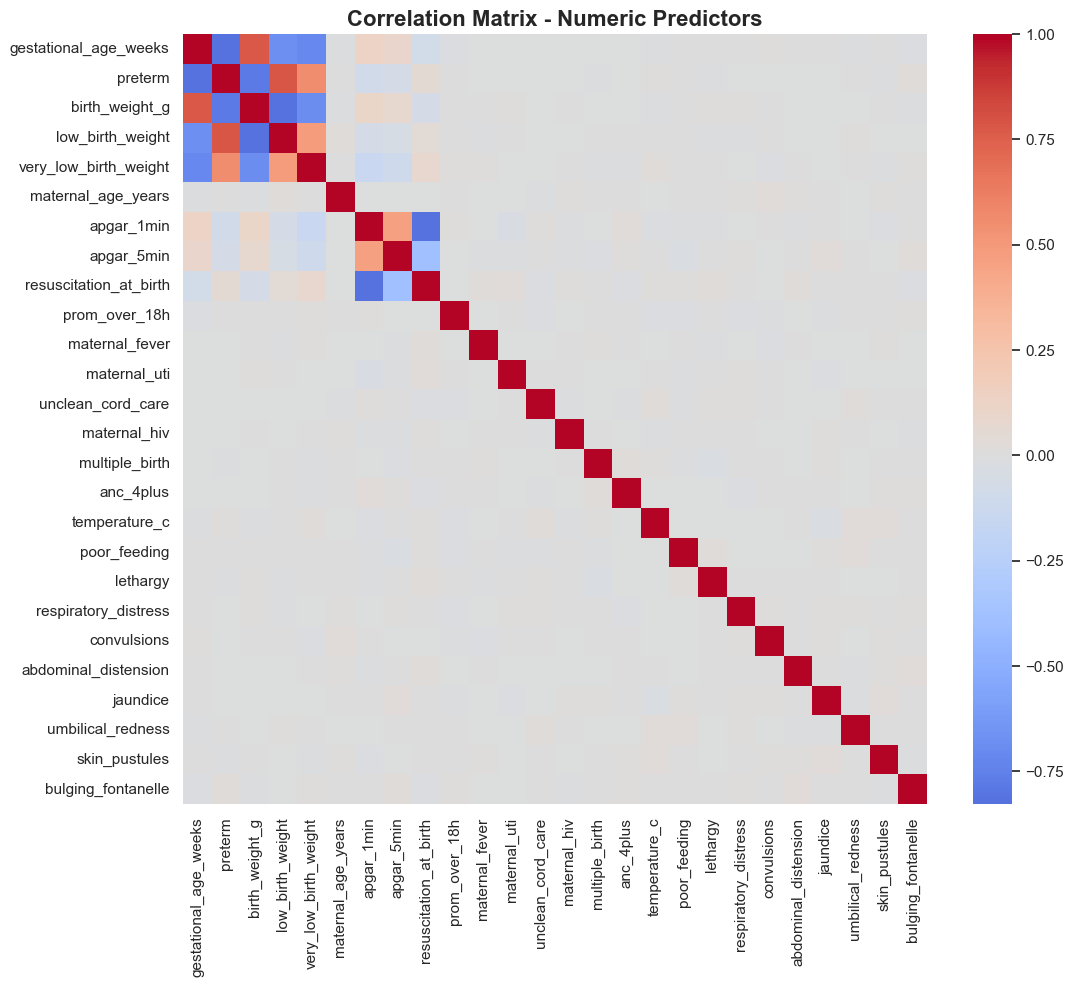

In [10]:
# check corrleation matrix for numerical values
numeric_features = df[features].select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(12,10))
corr_matrix = df[numeric_features].corr()

sns.heatmap(corr_matrix,
            cmap="coolwarm",
            center=0,
            annot=False)

plt.title("Correlation Matrix - Numeric Predictors", fontsize=16, weight='bold')
plt.show()

In [11]:
# print strong corrleations only
corr_pairs = corr_matrix.abs().unstack()
corr_pairs = corr_pairs.sort_values(ascending=False)

# Remove self-correlations
corr_pairs = corr_pairs[corr_pairs < 1]

high_corr = corr_pairs[corr_pairs > 0.80]
print(high_corr)

preterm                 gestational_age_weeks     0.827989
gestational_age_weeks   preterm                   0.827989
low_birth_weight        birth_weight_g            0.825103
birth_weight_g          low_birth_weight          0.825103
apgar_1min              resuscitation_at_birth    0.818855
resuscitation_at_birth  apgar_1min                0.818855
dtype: float64


## Data Preparation

Removed:
1) preterm
2) low_birth_weight
3) very_low_birth_weight
4) apgar_1min
5) resuscitation_at_birth

In [12]:
# Refine feature selection based on correlation findings

refined_features = [
    'sex',
    'gestational_age_weeks',
    'birth_weight_g',
    'delivery_mode',
    'place_of_birth',
    'maternal_age_years',
    'apgar_5min',
    'resuscitation_at_birth',
    'prom_over_18h',
    'maternal_fever',
    'maternal_uti',
    'unclean_cord_care',
    'maternal_hiv',
    'multiple_birth',
    'anc_4plus',
    'temperature_c',
    'poor_feeding',
    'lethargy',
    'respiratory_distress',
    'convulsions',
    'abdominal_distension',
    'jaundice',
    'umbilical_redness',
    'skin_pustules',
    'bulging_fontanelle',
    'severity'
]

target = 'length_of_stay_days'

### (onehotencoding and log transform target)

In [29]:
# Identify categorical vs numeric features
categorical_cols = ['sex', 'delivery_mode', 'place_of_birth', 'severity']
numeric_cols = [c for c in refined_features if c not in categorical_cols]

# One-hot encode categorical columns
# drop='first' prevents multicollinearity (avoids dummy variable trap)
encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded_cat = pd.DataFrame(
    encoder.fit_transform(df[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols),
    index=df.index  # IMPORTANT: keeps rows aligned with df
)

# Combine numeric and encoded categorical into final feature matrix X
X = pd.concat([df[numeric_cols], encoded_cat], axis=1)

# Log-transform LOS to reduce skew (common for LOS prediction)
y = np.log1p(df[target])

# Sanity checks: confirms what features are actually entering your model
print("Baseline X shape:", X.shape)
print("Baseline X sample columns:", X.columns.tolist()[:15])

Baseline X shape: (10000, 31)
Baseline X sample columns: ['gestational_age_weeks', 'birth_weight_g', 'maternal_age_years', 'apgar_5min', 'resuscitation_at_birth', 'prom_over_18h', 'maternal_fever', 'maternal_uti', 'unclean_cord_care', 'maternal_hiv', 'multiple_birth', 'anc_4plus', 'temperature_c', 'poor_feeding', 'lethargy']


## Train/Test Split 

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Training

In [15]:
# --- Linear Regression (baseline) ---
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on log scale, then convert back to days using expm1
y_pred_lr = np.expm1(lr.predict(X_test))

# --- Gradient Boosting Regressor (baseline) ---
gbr = GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=4, random_state=42
)
gbr.fit(X_train, y_train)
y_pred_gbr = np.expm1(gbr.predict(X_test))

# --- XGBoost Regressor (baseline) ---
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    objective='reg:squarederror'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = np.expm1(xgb_model.predict(X_test))

## Evalaution 

In [16]:
def evaluate_model(y_true_log, y_pred_days, name):
    # Convert the true values back from log scale to day scale
    y_true_days = np.expm1(y_true_log)

    mae = mean_absolute_error(y_true_days, y_pred_days)
    rmse = np.sqrt(mean_squared_error(y_true_days, y_pred_days))
    r2 = r2_score(y_true_days, y_pred_days)

    print(f"{name} Performance:")
    print(f"MAE: {mae:.2f} days")
    print(f"RMSE: {rmse:.2f} days")
    print(f"R²: {r2:.3f}\n")

evaluate_model(y_test, y_pred_lr, "Linear Regression (Baseline)")
evaluate_model(y_test, y_pred_gbr, "Gradient Boosting (Baseline)")
evaluate_model(y_test, y_pred_xgb, "XGBoost (Baseline)")

Linear Regression (Baseline) Performance:
MAE: 3.91 days
RMSE: 5.10 days
R²: -0.053

Gradient Boosting (Baseline) Performance:
MAE: 3.96 days
RMSE: 5.17 days
R²: -0.081

XGBoost (Baseline) Performance:
MAE: 3.97 days
RMSE: 5.17 days
R²: -0.082



## Visualization

### Actual vs Predicted

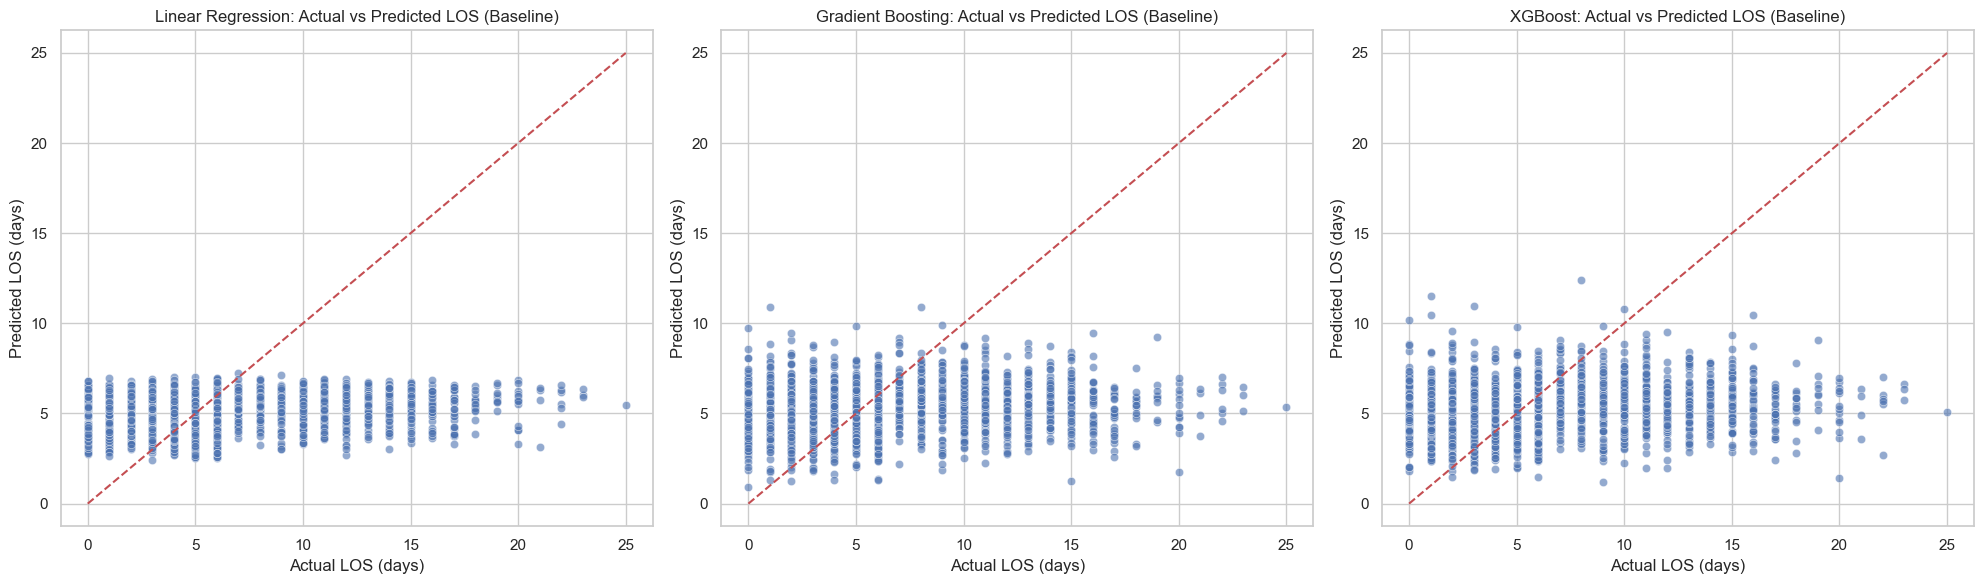

In [26]:
# Convert true y_test values back to days for plotting
y_test_actual = np.expm1(y_test)

# Create diagonal reference line max
max_val = max(y_test_actual.max(), y_pred_lr.max(), y_pred_gbr.max(), y_pred_xgb.max())

plt.figure(figsize=(20, 6))

# Linear Regression
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_test_actual, y=y_pred_lr, alpha=0.6)
plt.plot([0, max_val], [0, max_val], 'r--')
plt.title("Linear Regression: Actual vs Predicted LOS (Baseline)")
plt.xlabel("Actual LOS (days)")
plt.ylabel("Predicted LOS (days)")

# Gradient Boosting
plt.subplot(1, 3, 2)
sns.scatterplot(x=y_test_actual, y=y_pred_gbr, alpha=0.6)
plt.plot([0, max_val], [0, max_val], 'r--')
plt.title("Gradient Boosting: Actual vs Predicted LOS (Baseline)")
plt.xlabel("Actual LOS (days)")
plt.ylabel("Predicted LOS (days)")

# XGBoost
plt.subplot(1, 3, 3)
sns.scatterplot(x=y_test_actual, y=y_pred_xgb, alpha=0.6)
plt.plot([0, max_val], [0, max_val], 'r--')
plt.title("XGBoost: Actual vs Predicted LOS (Baseline)")
plt.xlabel("Actual LOS (days)")
plt.ylabel("Predicted LOS (days)")

plt.tight_layout()

# SAVE IMAGE HERE
plt.savefig("baseline_actual_vs_predicted.png", dpi=300, bbox_inches="tight")

plt.show()

### Feature importance

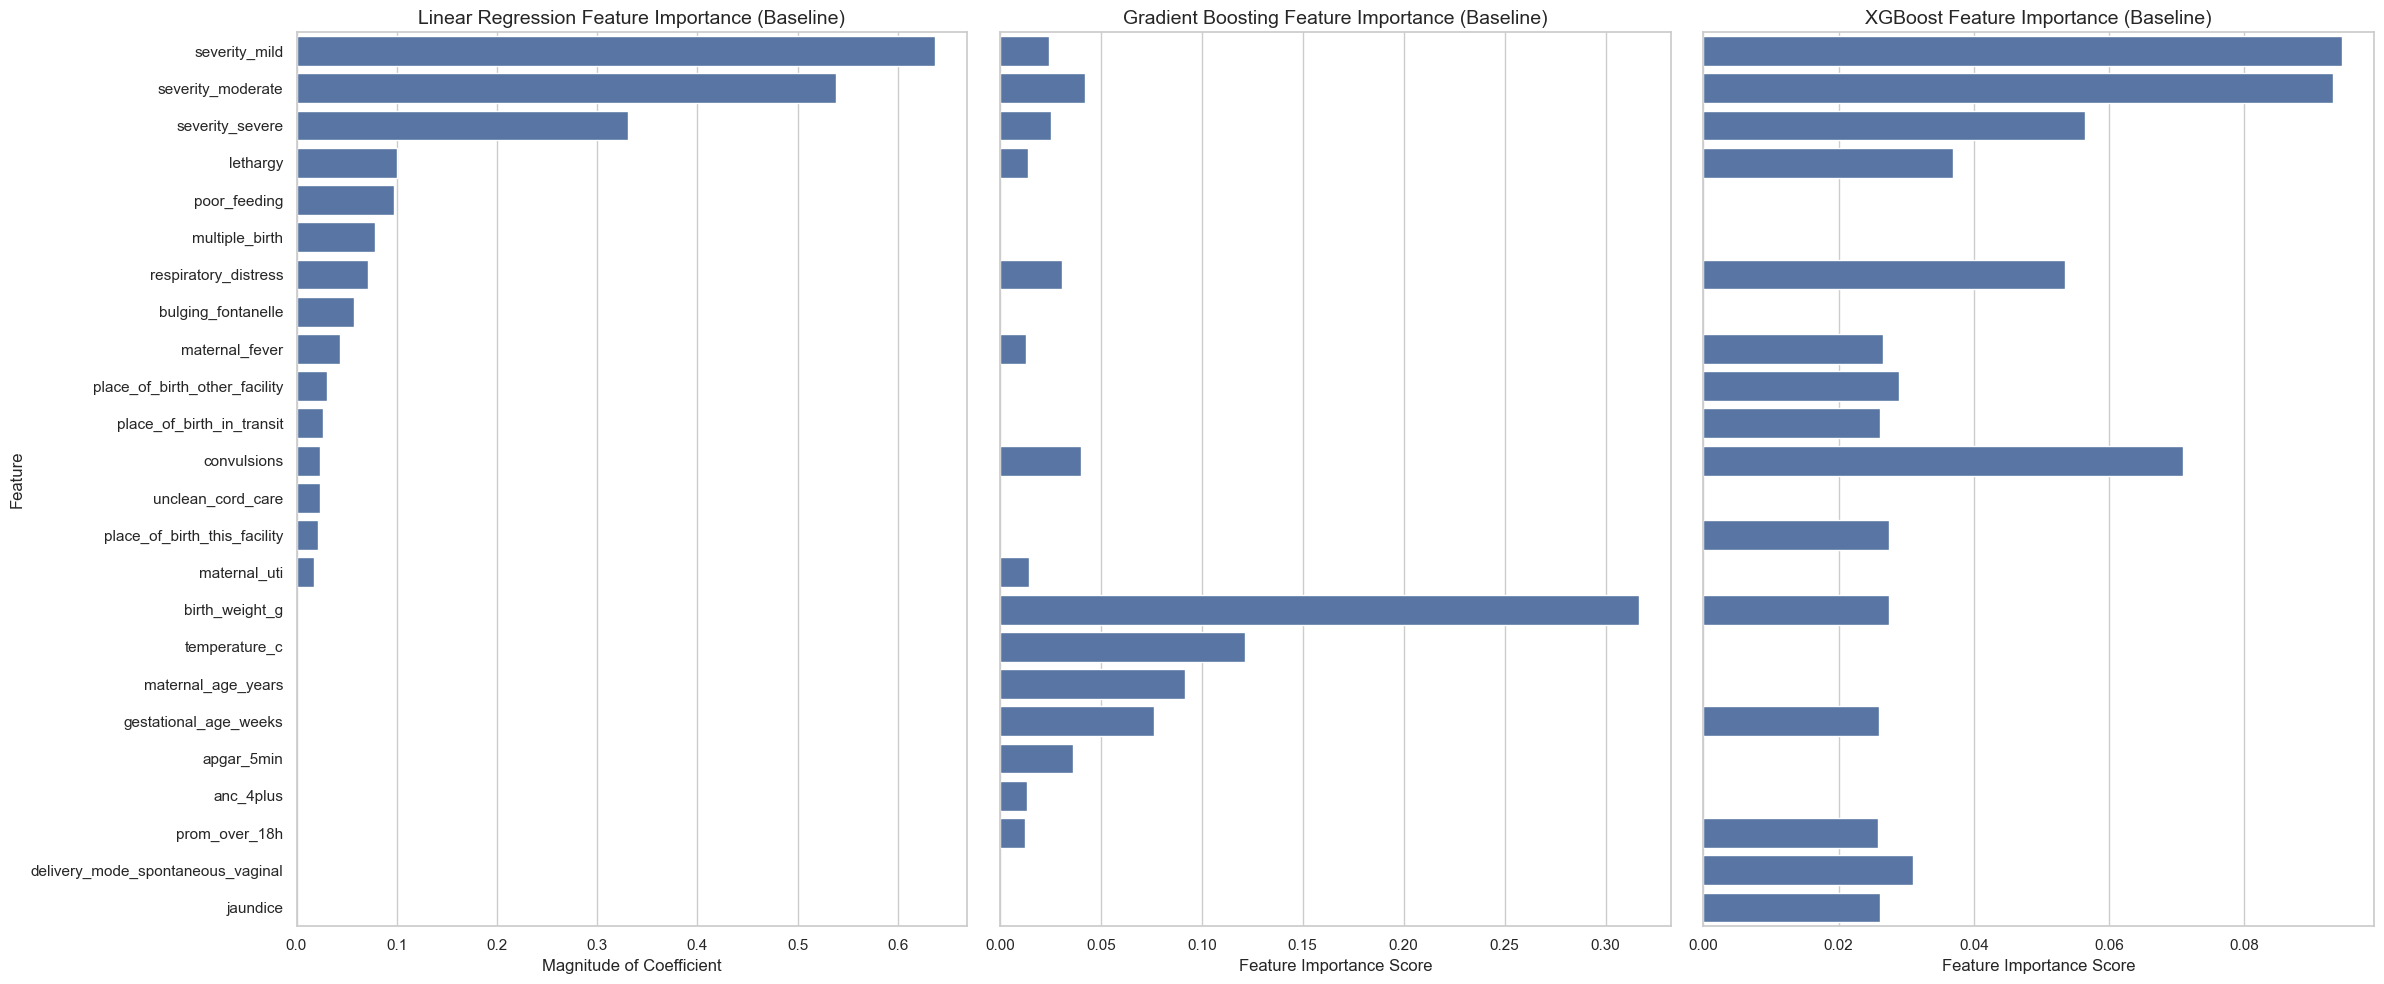

In [27]:
# --- Linear Regression importance = absolute value of coefficients ---
lr_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': np.abs(lr.coef_)
}).sort_values(by='Importance', ascending=False)

# --- Gradient Boosting importance ---
gbr_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gbr.feature_importances_
}).sort_values(by='Importance', ascending=False)

# --- XGBoost importance ---
xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(24, 10), sharey=True)

# Linear Regression
sns.barplot(
    x='Importance',
    y='Feature',
    data=lr_importance.head(15),
    ax=axes[0]
)
axes[0].set_title('Linear Regression Feature Importance (Baseline)', fontsize=14)
axes[0].set_xlabel('Magnitude of Coefficient')

# Gradient Boosting
sns.barplot(
    x='Importance',
    y='Feature',
    data=gbr_importance.head(15),
    ax=axes[1]
)
axes[1].set_title('Gradient Boosting Feature Importance (Baseline)', fontsize=14)
axes[1].set_xlabel('Feature Importance Score')

# XGBoost
sns.barplot(
    x='Importance',
    y='Feature',
    data=xgb_importance.head(15),
    ax=axes[2]
)
axes[2].set_title('XGBoost Feature Importance (Baseline)', fontsize=14)
axes[2].set_xlabel('Feature Importance Score')

plt.tight_layout()

# --- SAVE IMAGE (publication quality) ---
plt.savefig("baseline_feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

Overall Takeaways

No model is performing well. Slight differences in MAE/RMSE are negligible.

Negative R² indicates the features you’re may not have predictive power for the target variable, or the data might have a lot of noise.

Linear Regression slightly “beats” the others, but only marginally. The more complex models (Gradient Boosting, XGBoost) are not improving performance, likely due to limited signal in the features.

What drives LOS:

1. Severity dominates (especially in linear model)
2. Birth weight and gestational age matter
3. Temperature has signal
4. Some symptoms contribute

Admissioin variables alone explain little of the variance in LOS. Length of stay depends heavily on:

1. Response to treatment
2. Complications during hospitalization
3. Antibiotic course duration
4. Feeding tolerance progression
5. Hospital discharge practices

Those are NOT in included in the dataset.

## Improved Version (Feature Engineering + Comparision)

Changes:
1. Ordinal severity
2. Clinical score
3. Birth weight × gestational age interaction

In [19]:
# Save Baseline metrics into dataframe to comopare later
def metrics_row(model_name, y_true_log, y_pred_days):
    y_true_days = np.expm1(y_true_log)
    mae = mean_absolute_error(y_true_days, y_pred_days)
    rmse = np.sqrt(mean_squared_error(y_true_days, y_pred_days))
    r2 = r2_score(y_true_days, y_pred_days)
    return [model_name, mae, rmse, r2]

baseline_results = [
    metrics_row("Linear Regression (Baseline)", y_test, y_pred_lr),
    metrics_row("Gradient Boosting (Baseline)", y_test, y_pred_gbr),
    metrics_row("XGBoost (Baseline)", y_test, y_pred_xgb)
]
baseline_df = pd.DataFrame(baseline_results, columns=["Model", "MAE", "RMSE", "R2"])

### Feature Engineering

In [20]:
df_fe = df.copy()

# 1) Ordinal encode severity so models capture ordering (mild < moderate < severe)
severity_map = {'mild': 1, 'moderate': 2, 'severe': 3}
df_fe['severity_ord'] = df_fe['severity'].map(severity_map)

# If severity has any unexpected strings, fill with median ordinal
df_fe['severity_ord'] = df_fe['severity_ord'].fillna(df_fe['severity_ord'].median())

# 2) Create a clinical score by combining multiple symptom indicators
clinical_features = [
    'lethargy', 'poor_feeding', 'respiratory_distress', 'convulsions',
    'maternal_fever', 'jaundice', 'bulging_fontanelle', 'abdominal_distension'
]
df_fe['clinical_score'] = df_fe[clinical_features].sum(axis=1)

# 3) Add interaction feature: birth weight × gestational age
df_fe['bw_ga_interaction'] = df_fe['birth_weight_g'] * df_fe['gestational_age_weeks']

In [21]:
# immproved deature list (reduced/noise controlled version using engineered features)
improved_features = [
    'sex', 'delivery_mode', 'place_of_birth',   # still categorical
    'maternal_age_years', 'apgar_5min',
    'resuscitation_at_birth', 'prom_over_18h', 'multiple_birth',
    'temperature_c', 'birth_weight_g', 'gestational_age_weeks',
    'severity_ord', 'clinical_score', 'bw_ga_interaction'
]

improved_cat = ['sex', 'delivery_mode', 'place_of_birth']
improved_num = [c for c in improved_features if c not in improved_cat]

# Fill missing values
df_fe[improved_num] = df_fe[improved_num].fillna(df_fe[improved_num].median())
df_fe[improved_cat] = df_fe[improved_cat].fillna('Unknown')

# Encode improved categorical columns
encoder2 = OneHotEncoder(drop='first', sparse_output=False)
encoded2 = pd.DataFrame(
    encoder2.fit_transform(df_fe[improved_cat]),
    columns=encoder2.get_feature_names_out(improved_cat),
    index=df_fe.index
)

# Final improved X and y
X2 = pd.concat([df_fe[improved_num], encoded2], axis=1)
y2 = np.log1p(df_fe[target])

print("Improved X2 shape:", X2.shape)
print("Improved X2 sample columns:", X2.columns.tolist()[:15])

# Split (same random_state for fair comparison)
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# Train improved models
lr2 = LinearRegression()
lr2.fit(X_train2, y_train2)
y_pred_lr2 = np.expm1(lr2.predict(X_test2))

gbr2 = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, random_state=42)
gbr2.fit(X_train2, y_train2)
y_pred_gbr2 = np.expm1(gbr2.predict(X_test2))

xgb2 = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4,
                    random_state=42, objective='reg:squarederror')
xgb2.fit(X_train2, y_train2)
y_pred_xgb2 = np.expm1(xgb2.predict(X_test2))

# Store improved results
improved_results = [
    metrics_row("Linear Regression (Improved)", y_test2, y_pred_lr2),
    metrics_row("Gradient Boosting (Improved)", y_test2, y_pred_gbr2),
    metrics_row("XGBoost (Improved)", y_test2, y_pred_xgb2)
]
improved_df = pd.DataFrame(improved_results, columns=["Model", "MAE", "RMSE", "R2"])

# Combine baseline + improved into one table
comparison_df = pd.concat([baseline_df, improved_df], ignore_index=True)
comparison_df

Improved X2 shape: (10000, 17)
Improved X2 sample columns: ['maternal_age_years', 'apgar_5min', 'resuscitation_at_birth', 'prom_over_18h', 'multiple_birth', 'temperature_c', 'birth_weight_g', 'gestational_age_weeks', 'severity_ord', 'clinical_score', 'bw_ga_interaction', 'sex_M', 'delivery_mode_caesarean_section', 'delivery_mode_spontaneous_vaginal', 'place_of_birth_in_transit']


,Model,MAE,RMSE,R2
0,Linear Regression (Baseline),3.908795,5.102795,-0.052584
1,Gradient Boosting (Baseline),3.959689,5.171270,-0.081024
2,XGBoost (Baseline),3.966311,5.173944,-0.082142
3,Linear Regression (Improved),3.945038,5.153250,-0.073503
4,Gradient Boosting (Improved),3.990138,5.197593,-0.092057
5,XGBoost (Improved),3.979874,5.194710,-0.090846


### Visualize improvement in metrics

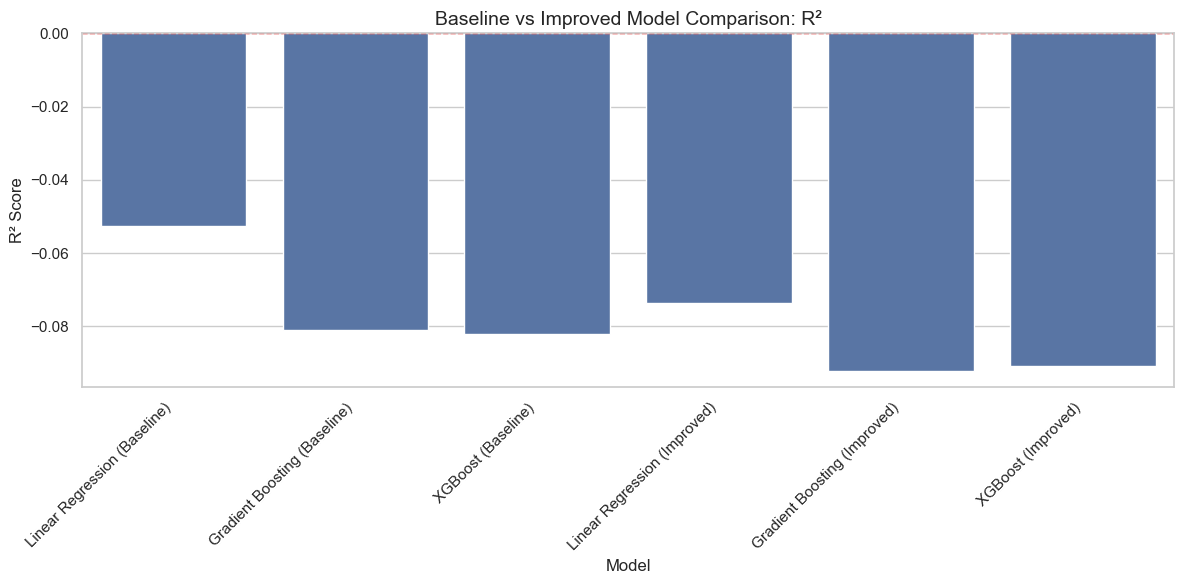

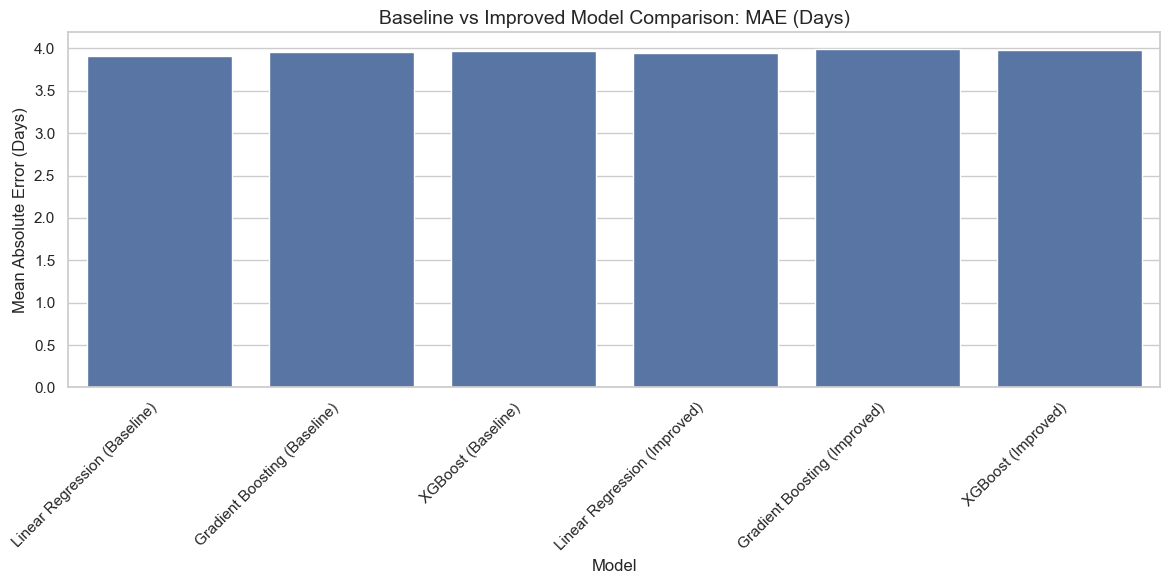

In [28]:
# R2 Comparision Plot

plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="R2"
)

plt.axhline(0, linestyle="--", color="red", linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.title("Baseline vs Improved Model Comparison: R²", fontsize=14)
plt.ylabel("R² Score")
plt.xlabel("Model")

plt.tight_layout()

# SAVE IMAGE
plt.savefig("model_r2_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

# MAE Comparision Plot
plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="MAE"
)

plt.xticks(rotation=45, ha="right")
plt.title("Baseline vs Improved Model Comparison: MAE (Days)", fontsize=14)
plt.ylabel("Mean Absolute Error (Days)")
plt.xlabel("Model")

plt.tight_layout()

# SAVE IMAGE
plt.savefig("model_mae_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

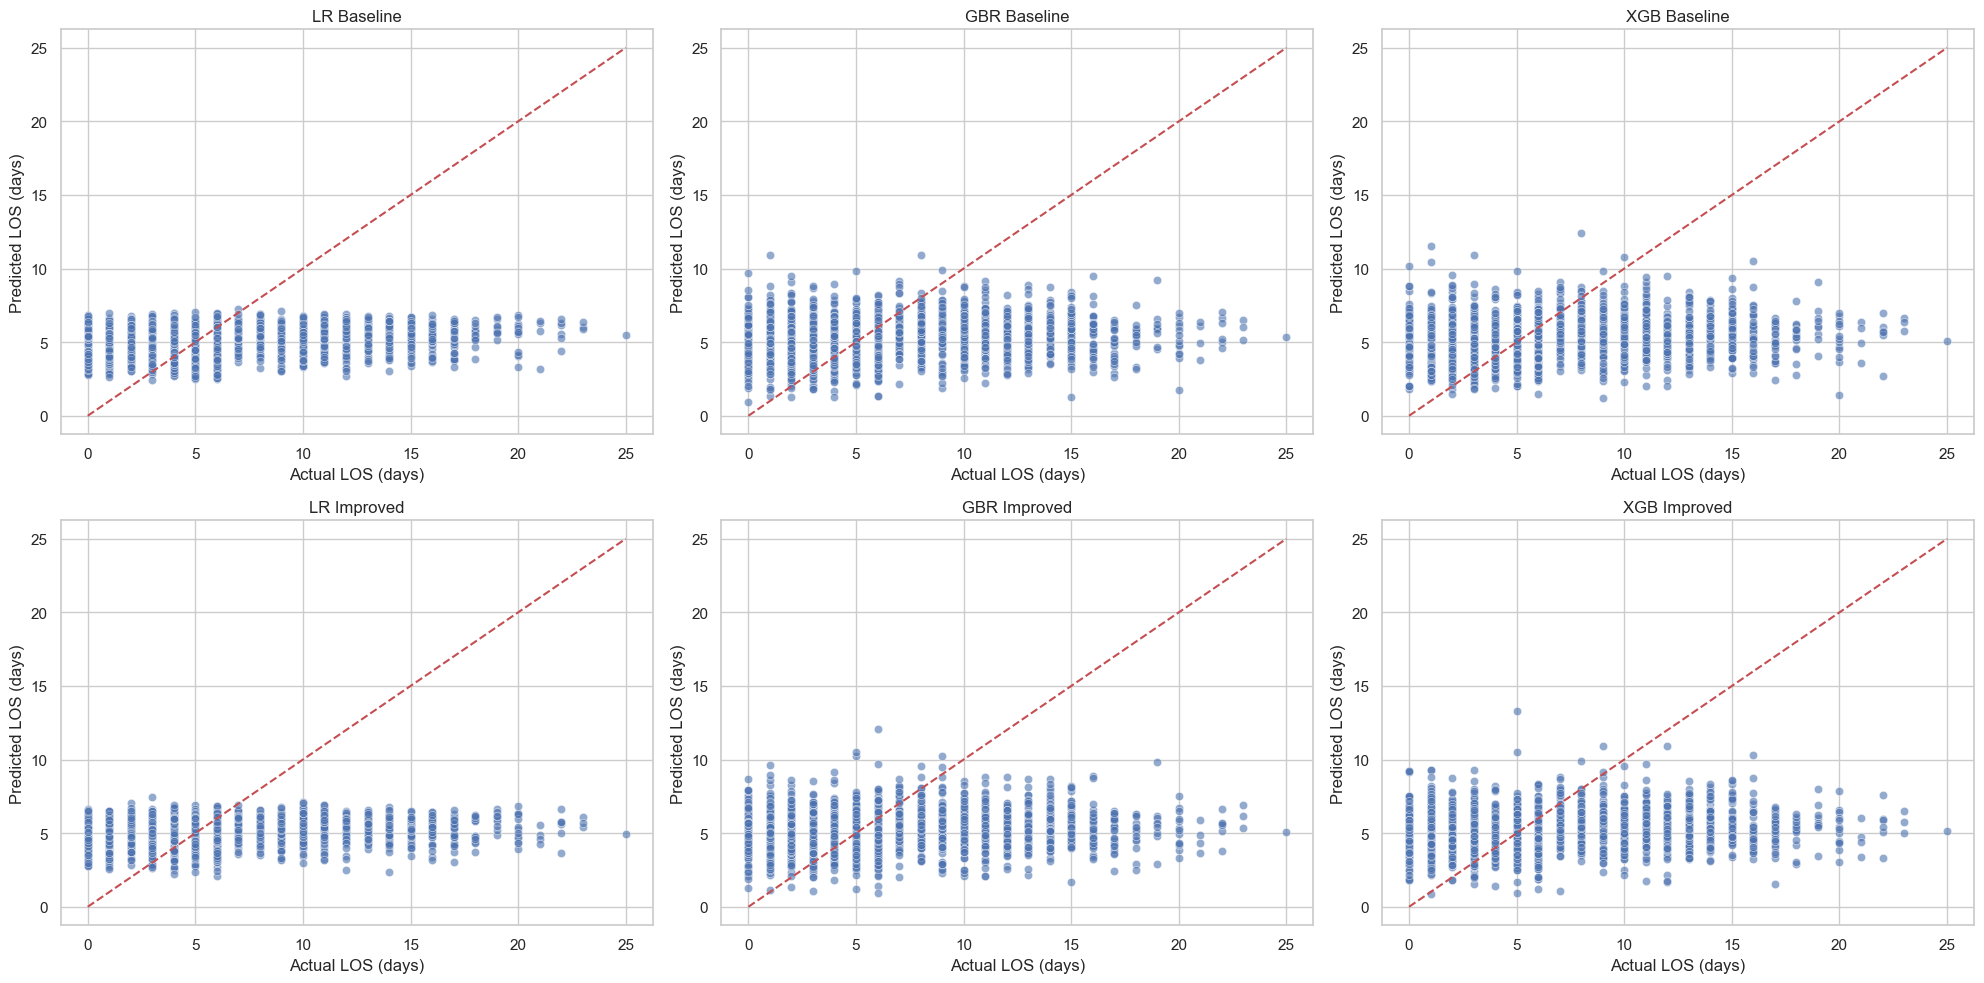

In [23]:
# Baseline vs Improved Scatter plots
y_test_actual2 = np.expm1(y_test2)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Top row = baseline
max_base = max(y_test_actual.max(), y_pred_lr.max(), y_pred_gbr.max(), y_pred_xgb.max())
sns.scatterplot(x=y_test_actual, y=y_pred_lr, alpha=0.6, ax=axes[0,0])
axes[0,0].plot([0, max_base], [0, max_base], 'r--'); axes[0,0].set_title("LR Baseline")

sns.scatterplot(x=y_test_actual, y=y_pred_gbr, alpha=0.6, ax=axes[0,1])
axes[0,1].plot([0, max_base], [0, max_base], 'r--'); axes[0,1].set_title("GBR Baseline")

sns.scatterplot(x=y_test_actual, y=y_pred_xgb, alpha=0.6, ax=axes[0,2])
axes[0,2].plot([0, max_base], [0, max_base], 'r--'); axes[0,2].set_title("XGB Baseline")

# Bottom row = improved
max_imp = max(y_test_actual2.max(), y_pred_lr2.max(), y_pred_gbr2.max(), y_pred_xgb2.max())
sns.scatterplot(x=y_test_actual2, y=y_pred_lr2, alpha=0.6, ax=axes[1,0])
axes[1,0].plot([0, max_imp], [0, max_imp], 'r--'); axes[1,0].set_title("LR Improved")

sns.scatterplot(x=y_test_actual2, y=y_pred_gbr2, alpha=0.6, ax=axes[1,1])
axes[1,1].plot([0, max_imp], [0, max_imp], 'r--'); axes[1,1].set_title("GBR Improved")

sns.scatterplot(x=y_test_actual2, y=y_pred_xgb2, alpha=0.6, ax=axes[1,2])
axes[1,2].plot([0, max_imp], [0, max_imp], 'r--'); axes[1,2].set_title("XGB Improved")

for ax in axes.flat:
    ax.set_xlabel("Actual LOS (days)")
    ax.set_ylabel("Predicted LOS (days)")

plt.tight_layout()
tplt.show()

Takeaway:
1. Baseline is best (even though it’s weak overall).
2. feature engineering (severity ordinal + clinical score + interaction) didn’t add predictive signal and likely removed useful signal (by dropping many original predictors and/or changing the feature space).
3. Negative R² across the board means: the models are performing worse than a naive model that predicts the average LOS for everyone.
4. Best model in your run is Linear Regression (Baseline):
MAE ≈ 3.91 days, RMSE ≈ 5.10 days, R² ≈ -0.053
4. Improved Linear Regression got worse:
MAE increased (~+0.04 days), RMSE increased (~+0.05 days), R² more negative
5. Tree models also worsened slightly.
6. Admission-time variables alone may not be enough to predict LOS in this dataset.
7. LOS is heavily influenced by things you may not have (or not using fully), like:
- complications that happen after admission
- treatment response over time
- hospital discharge policies / capacity / workflow
- severity changes during stay
- timing and escalation of respiratory support, antibiotics, feeding progression, etc.

Conclusion:
- “NICU LOS in this dataset shows limited predictability from admission clinical/demographic features, suggesting that post-admission clinical course and operational factors play a larger role.”